# 🍎 Exploratory Data Analysis (EDA) - FruitFresh AI
## Klasifikasi Kualitas dan Kesegaran Buah Berbasis Deep Learning

Notebook ini bertujuan untuk melakukan analisis eksplorasi data (EDA) pada dataset citra buah sebelum proses pelatihan model. Analisis meliputi:
1. **Pemeriksaan Integritas & Ketersediaan Dataset**
2. **Jumlah Data & Distribusi Setiap Kelas**
3. **Visualisasi Sampel Citra Setiap Kelas**
4. **Analisis Variasi Ukuran/Resolusi Citra**
5. **Analisis Ketidakseimbangan Data (Class Imbalance) & Dampak Teoretisnya**

In [1]:
import os
import sys
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set path ke root project
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_loader import inspect_dataset, print_dataset_summary, find_dataset_dir, VALID_EXTENSIONS

print("Project Root:", project_root)
sns.set_theme(style="whitegrid")

Project Root: C:\Users\PC\Documents\Projekl\Projek ML Fresh Fruit


--- 
## 1. Pemeriksaan Struktur & Validasi Dataset
Memindai dataset pada folder `dataset/` untuk mengekstrak kelas sebenarnya dan memvalidasi file korup.

In [2]:
summary = inspect_dataset()
print_dataset_summary(summary)


[INFO] Memindai dataset pada direktori: C:\Users\PC\Documents\Projekl\Projek ML Fresh Fruit\dataset


        LAPORAN PEMERIKSAAN DATASET BUAH (FruitFresh AI)
Lokasi Dataset : C:\Users\PC\Documents\Projekl\Projek ML Fresh Fruit\dataset
Jumlah Class   : 6
Daftar Class   : freshapples, freshbanana, freshoranges, rottenapples, rottenbanana, rottenoranges
Total Gambar   : 13,599 file
------------------------------------------------------------
DISTRIBUSI GAMBAR PER CLASS:
  • freshapples          :  2088 gambar ( 15.4%)
  • freshbanana          :  1962 gambar ( 14.4%)
  • freshoranges         :  1854 gambar ( 13.6%)
  • rottenapples         :  2943 gambar ( 21.6%)
  • rottenbanana         :  2754 gambar ( 20.3%)
  • rottenoranges        :  1998 gambar ( 14.7%)
------------------------------------------------------------
DISTRIBUSI EKSTENSI FILE:
  • [tanpa ekstensi] : 1 file
  • .png       : 13599 file
------------------------------------------------------------
File Corrupt/Rusak : 0 file


--- 
## 2. Analisis Distribusi Kelas Dataset
Membuat DataFrame untuk mempermudah kalkulasi statistik dan visualisasi distribusi.

In [3]:
dataset_dir, _ = find_dataset_dir()
data_records = []

if dataset_dir and summary.get('status') == 'OK':
    for root, _, files in os.walk(dataset_dir):
        for file in files:
            p = Path(root) / file
            if p.suffix.lower() in VALID_EXTENSIONS:
                cls_name = p.parent.name
                if cls_name.lower() not in {'train', 'test', 'val'}:
                    data_records.append({
                        'filepath': str(p),
                        'filename': p.name,
                        'class_name': cls_name,
                        'extension': p.suffix.lower()
                    })
    df = pd.DataFrame(data_records)
    print(f"Total data yang terindeks: {len(df)} gambar")
    print(df['class_name'].value_counts())
else:
    df = pd.DataFrame(columns=['filepath', 'filename', 'class_name', 'extension'])
    print("Dataset belum tersedia di folder 'dataset/'. Silakan masukkan dataset terlebih dahulu.")

Total data yang terindeks: 13599 gambar
class_name
rottenapples     2943
rottenbanana     2754
freshapples      2088
rottenoranges    1998
freshbanana      1962
freshoranges     1854
Name: count, dtype: int64


C:\Users\PC\AppData\Local\Temp\ipykernel_8356\1715681222.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=counts, x='class_name', y='count', palette='viridis')


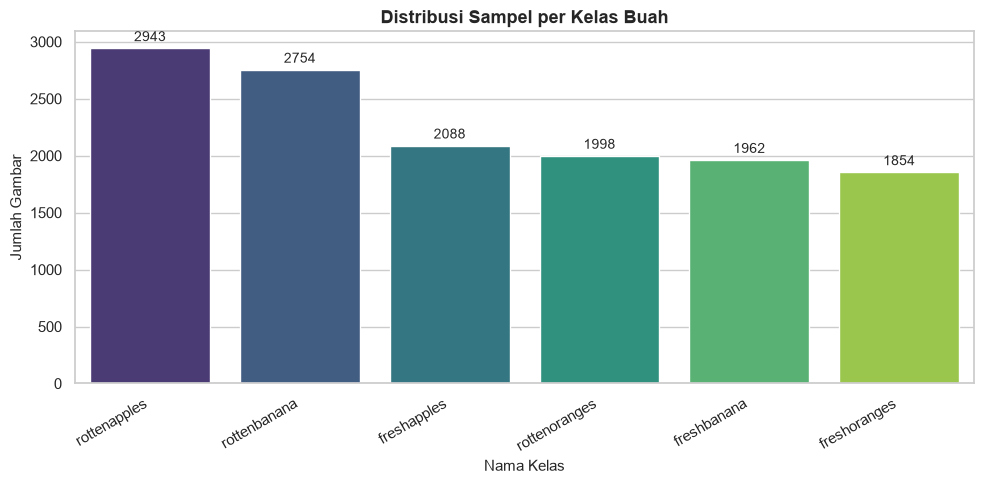

In [4]:
if not df.empty:
    plt.figure(figsize=(10, 5))
    counts = df['class_name'].value_counts().reset_index()
    counts.columns = ['class_name', 'count']
    
    ax = sns.barplot(data=counts, x='class_name', y='count', palette='viridis')
    plt.title('Distribusi Sampel per Kelas Buah', fontsize=13, fontweight='bold')
    plt.xlabel('Nama Kelas', fontsize=11)
    plt.ylabel('Jumlah Gambar', fontsize=11)
    plt.xticks(rotation=30, ha='right')
    
    for p in ax.patches:
        height = int(p.get_height())
        ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 3),
                    textcoords='offset points')
                    
    plt.tight_layout()
    plt.show()

--- 
## 3. Visualisasi Contoh Citra untuk Setiap Kelas
Menampilkan grid citra aktual dari setiap kelas buah untuk mengamati karakteristik visual (warna, bercak busuk, tekstur kulit).

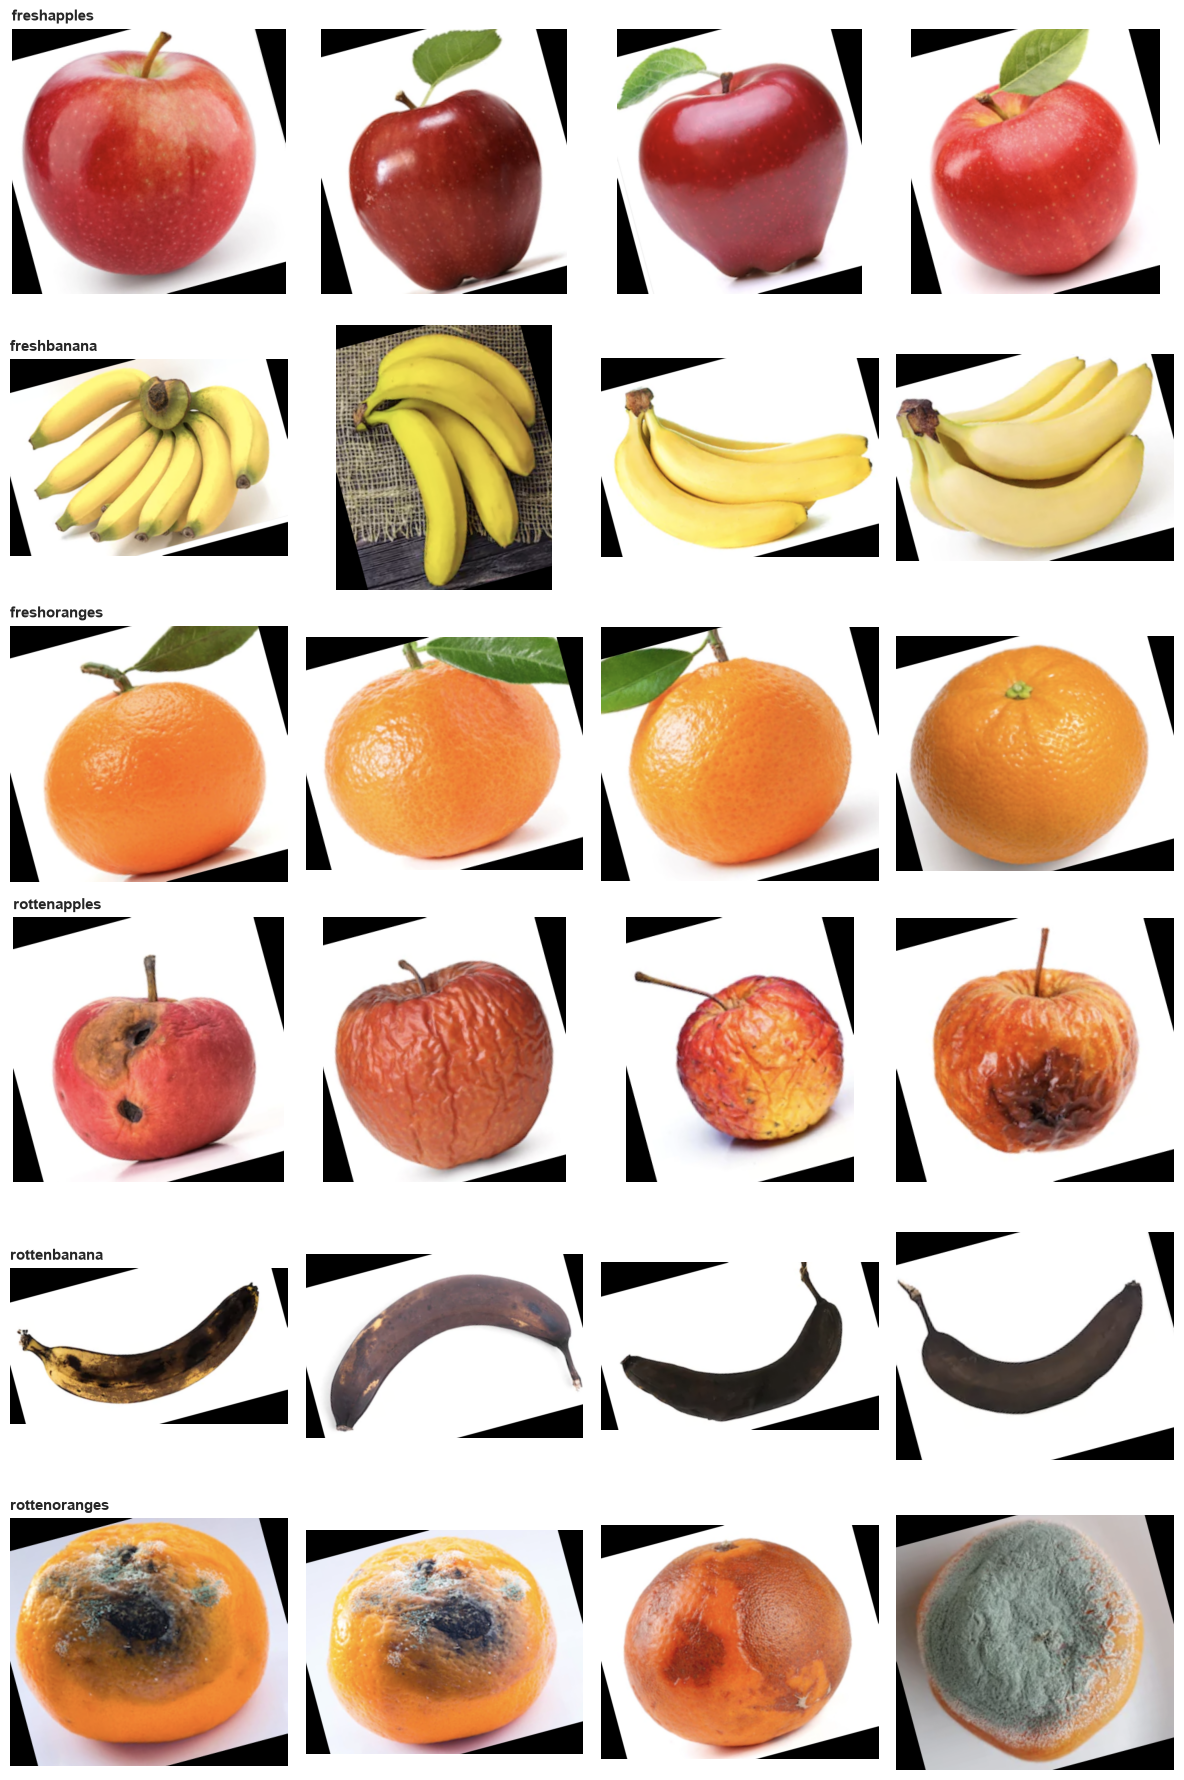

In [5]:
if not df.empty:
    classes = sorted(df['class_name'].unique())
    fig, axes = plt.subplots(len(classes), 4, figsize=(12, 3 * len(classes)))
    if len(classes) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, cls in enumerate(classes):
        sample_paths = df[df['class_name'] == cls]['filepath'].head(4).values
        for j, img_p in enumerate(sample_paths):
            ax = axes[i, j]
            with Image.open(img_p) as img:
                ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f"{cls}", fontsize=11, fontweight='bold', loc='left')
                
    plt.tight_layout()
    plt.show()

--- 
## 4. Analisis Ukuran & Rasio Aspek Citra Asli
Sebelum di-resize ke `(224, 224)` untuk input MobileNetV2, penting untuk melihat seberapa besar variasi dimensi gambar asli.

Statistik Resolusi Gambar (Sample):


,width,height,aspect_ratio
count,300.000000,300.000000,300.000000
mean,416.413333,357.080000,1.166248
std,124.694848,78.009734,0.230478
min,150.000000,140.000000,0.531532
25%,334.000000,319.500000,1.020788
50%,402.000000,366.000000,1.117447
75%,500.000000,414.000000,1.277034
max,796.000000,518.000000,1.903614


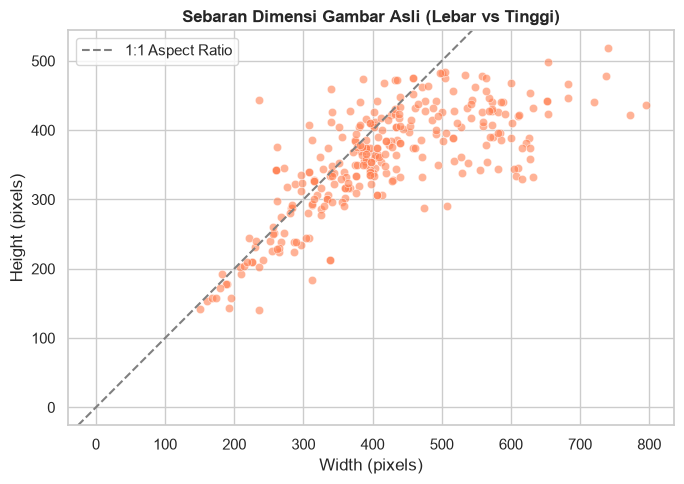

In [6]:
if not df.empty:
    # Sample maksimal 300 gambar untuk efisiensi pembacaan dimensi
    sample_df = df.sample(min(300, len(df)), random_state=42)
    dimensions = []
    
    for p in sample_df['filepath']:
        try:
            with Image.open(p) as img:
                w, h = img.size
                dimensions.append({'width': w, 'height': h, 'aspect_ratio': w / h})
        except Exception:
            continue
            
    dim_df = pd.DataFrame(dimensions)
    print("Statistik Resolusi Gambar (Sample):")
    display(dim_df.describe())
    
    # Scatter plot dimensi
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=dim_df, x='width', y='height', alpha=0.6, color='coral')
    plt.title('Sebaran Dimensi Gambar Asli (Lebar vs Tinggi)', fontsize=12, fontweight='bold')
    plt.xlabel('Width (pixels)')
    plt.ylabel('Height (pixels)')
    plt.axline((0, 0), slope=1, color='gray', linestyle='--', label='1:1 Aspect Ratio')
    plt.legend()
    plt.tight_layout()
    plt.show()

--- 
## 5. Analisis Ketidakseimbangan Data (Class Imbalance) & Dampak Teoretis

### Teori & Penjelasan Akademis:
1. **Apa itu Ketidakseimbangan Data (Class Imbalance)?**
   - Kondisi di mana jumlah sampel pada satu atau lebih kelas jauh lebih sedikit (minoritas) dibanding kelas lainnya (mayoritas).

2. **Dampak terhadap Model Deep Learning:**
   - **Bias Prediksi:** Model cenderung memprioritaskan prediksi ke kelas mayoritas untuk meminimalkan loss fungsi secara cepat.
   - **Akurasi Semu (Accuracy Paradox):** Model bisa menunjukkan akurasi tinggi (misal 90%), padahal performa pada kelas minoritas sangat buruk (Recall rendah).
   - **Gradient Dominance:** Pembaruan bobot model saat *backpropagation* akan didominasi oleh gradien dari kelas mayoritas.

3. **Solusi yang Diterapkan dalam Proyek Ini:**
   - **Stratified Data Splitting:** Memastikan proporsi kelas pada *Train (70%)*, *Validation (15%)*, dan *Test (15%)* tetap identik.
   - **Data Augmentation:** Menghasilkan variasi citra buatan realistis untuk memperkaya representasi fitur.
   - **Evaluasi Multi-Metrik:** Tidak hanya mengandalkan *Accuracy*, melainkan menggunakan **Macro Precision, Macro Recall, dan F1-Score** serta **Confusion Matrix**.